# **Notebook 1** - Discovering & Retrieving Seismic Data

### MVP1 goals: Data discovery, dataset selection, data retrieval, data store

This is the first notebook in the GeoLab seismic learning pathway. By the end you will be able to start with only a map of stations and time-window and walk away with seismic waveforms that your science needs. The data will be streamed from the cloud. There is no need to download on your local workstation anymore.

##### **Traditional way**

Point an FTP client or web form --> pull gigabytes of data onto local disk --> figure out what is needed

##### **GeoLab way**
Discover what exists --> scope it to your science question --> stream only the bytes you need

All inside the same cloud, where data lives

Instead of asking "what files should I download?", a cloud-optimized workflow allows for the user a better sequence of questions:

1. What event or time-window matters for my science question?
2. Which stations nad channels were operating then?
3. Which of those stations actually have waveform data?
4. How much data will this request stream?

When using cloud platform, such as **GeoLab**, it is possible for users to iterate through these steps multiple times with much better time efficiency than using a local workstation. The reason is, in **GeoLab** you are computing near data.

<u>Assumed background</u>

This notebook assumes basic familiarity with Python, pandas, plotting, and ObsPy. You do not need to know cloud computing in advance, but you are expected to go through the notebooks in the `Cloud Foundations` offered by EarthScope.

---

## **1. Data discovery**

Cloud workflows begin with discovery, not downloads.

In this section, we use ObsPy to ask small metadata questions before requesting waveform data:

1. Which earthquakes match our region, time range, and magnitude threshold?
2. Which seismic stations were operating near the event time?
3. Which station/channel combinations are likely to have usable waveform data?

This matters because metadata queries are lightweight. They let us narrow the problem before moving waveform data across the network.

#### **1.1 Connect to EarthScope FDSN web service**

Opening a `Client` only means setting up the connection to EarthScope.

In [7]:
# Create an FDSN client for EarthScope services.
# This client will be used for station metadata and waveform requests.
from obspy.clients.fdsn import Client
client = Client("https://service.earthscope.org") # previously "IRIS"
print(client)

FDSN Webservice Client (base url: https://service.earthscope.org)
Available Services: 'dataselect' (v1.1.64), 'station' (v1.1.53)

Use e.g. client.help('dataselect') for the
parameter description of the individual services
or client.help() for parameter description of
all webservices.


#### **1.2 Build an event catalog**


We query earthquake **catalogs** from the USGS event service, while **waveforms** come from EarthScope. We point the `event` service at USGS in the next cell, and everything else keeps using EarthScope under the hood.

At this stage, we are not moving waveform data yet. We are only retrieving event metadata: origin time, location, depth, and magnitude. This is the “cheap query” stage of the workflow.

> ✏️ Set parameters to search for earthquakes. First, a geographic bounding box, which is just four numbers: the min/max latitude and min/max longitude. We default to a box over West Washington, USA. You can make it bigger, smaller, or move it somewhere else entirely. Then, set your preferred time range and minimum magnitude.

In [8]:
# ---- USER INPUTS -----
# Geographic bounding box for the region of interest (Default is the west Washington region)
min_lat, max_lat = 46, 48.5      # south / north edges
min_lon, max_lon = -125.5, -122.5  # west  / east  
stime = "2000-01-01"  # start date
etime = "2025-12-31"  # end date
minmagnitude = 4      # minimum magnitude of events to retrieve
# ----------------------

# Re-create the client with the EVENT service pointed at USGS.
# Only the 'event' endpoint is overridden; station/waveform calls still go to EarthScope by default 
from obspy import UTCDateTime
client  = Client(service_mappings={"event": "https://earthquake.usgs.gov/fdsnws/event/1"})
ev_catalog = client.get_events(minlatitude=min_lat, maxlatitude=max_lat, 
                            minlongitude=min_lon, maxlongitude=max_lon,
                            starttime=UTCDateTime(stime), endtime=UTCDateTime(etime), 
                            minmagnitude=minmagnitude)
print(ev_catalog)

10 Event(s) in Catalog:
2023-12-24T15:14:04.220000Z | +47.820, -122.960 | 4.04 ml | manual
2023-10-09T02:21:08.960000Z | +48.040, -122.731 | 4.31 ml | manual
2018-11-19T11:09:13.130000Z | +47.711, -123.554 | 4.08 ml | manual
2017-02-23T04:59:04.050000Z | +47.480, -123.035 | 4.09 ml | manual
2009-01-30T13:25:03.760000Z | +47.786, -122.585 | 4.67 ml | manual
2003-04-25T10:02:12.710000Z | +47.670, -123.250 | 4.8  md | manual
2002-09-21T00:55:20.960000Z | +48.485, -123.126 | 4.1  md | manual
2001-07-22T15:13:52.430000Z | +47.088, -122.687 | 4.3  md | manual
2001-06-10T13:19:11.290000Z | +47.167, -123.502 | 5.0  md | manual
2001-02-28T18:54:32.830000Z | +47.149, -122.727 | 6.8  md | manual


#### **1.3 Visualize events**

                    event_time   latitude   longitude  magnitude
0  2023-12-24T15:14:04.220000Z  47.819667 -122.960000       4.04
1  2023-10-09T02:21:08.960000Z  48.040167 -122.730833       4.31
2  2018-11-19T11:09:13.130000Z  47.711333 -123.554167       4.08
3  2017-02-23T04:59:04.050000Z  47.480167 -123.035000       4.09
4  2009-01-30T13:25:03.760000Z  47.786500 -122.584667       4.67
5  2003-04-25T10:02:12.710000Z  47.670500 -123.250000       4.80
6  2002-09-21T00:55:20.960000Z  48.484833 -123.126500       4.10
7  2001-07-22T15:13:52.430000Z  47.087833 -122.686833       4.30
8  2001-06-10T13:19:11.290000Z  47.167500 -123.502500       5.00
9  2001-02-28T18:54:32.830000Z  47.149000 -122.726667       6.80


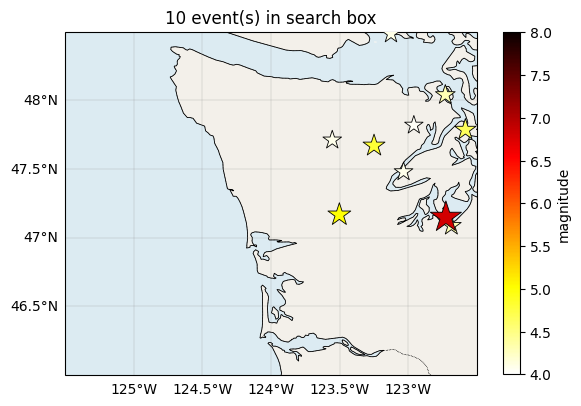

In [66]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Unpack location + magnitude from every event in the catalog.
evlats, evlons, evmags, evtime = [], [], [], []
for ev in ev_catalog:
    origin = ev.preferred_origin() or ev.origins[0]
    mag = ev.preferred_magnitude() or (ev.magnitudes[0] if ev.magnitudes else None)
    depth_km = (origin.depth or 0) / 1000.0    
    time = ev.origins[0].time
    evlats.append(origin.latitude); evlons.append(origin.longitude); 
    evmags.append(mag.mag if mag else None)
    evtime.append(time)

# Create a Pandas DataFrame for the events, which will be useful for further analysis.
import pandas as pd
df_events = pd.DataFrame({
    "event_time": evtime,
    "latitude": evlats,
    "longitude": evlons,
    "magnitude": evmags
})
print(df_events)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Basemap context. The first time this runs, cartopy downloads the coastline /
# land shapefiles (a few seconds), then caches them for next time.
ax.add_feature(cfeature.LAND,  facecolor="#f3f0ea")
ax.add_feature(cfeature.OCEAN, facecolor="#dcebf2")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.STATES, linestyle=":", linewidth=0.4)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = gl.right_labels = False

# Marker size grows with magnitude so big events stand out
sizes = [(m ** 2) * 12 for m in evmags]
sc = ax.scatter(evlons, evlats, s=sizes, c=evmags, cmap="hot_r",
                marker="*", edgecolors="black", linewidths=0.6,
                vmin=4, vmax=8, transform=ccrs.PlateCarree(), zorder=5)
plt.colorbar(sc, ax=ax, shrink=0.6, label="magnitude")

ax.set_title(f"{len(ev_catalog)} event(s) in search box")
plt.tight_layout()
plt.show()

#### **1.4 Select preferred event & define parameters to make a station inventory**

A station inventory is more than a list of stations. It tells us which networks, stations, locations, and channels existed during the event window.

> ✏️ Select your earthquake from the catalog above, and copy its origin time. You will also need channel codes for your interested channels.

Channel codes follow the SEED convention. First letter = band; second = instrument
- `HN?` — strong-motion accelerometer (great for big, nearby quakes — what we use here)
- `BH?` / `HH?` — broadband seismometer (3 components: Z/N/E)
- `EH?` — short-period

The `?` is a single-character wildcard, so `HN?` grabs all three components (HNZ/HNN/HNE).

In [30]:
# ---- USER INPUTS -----
# Select preferred event
event_time = UTCDateTime("2018-11-19T11:09:13.130000")
target_channel = "HN?" 
# A time window around the event to search for stations, operating at the time of the event.
t1 = event_time - 120     # 2 min before origin
t2 = event_time + 480     # 8 min after origin
# ----------------------

# Search for stations that were operating during the event window.
# level="response" includes the instrument response
st_inv = client.get_stations(
    minlatitude=min_lat, maxlatitude=max_lat, 
    minlongitude=min_lon, maxlongitude=max_lon,
    channel=target_channel, starttime=t1, endtime=t2,
    level="response",
)

st_inv

Inventory created at 2026-06-26T05:18:00.468800Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2018-11-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (5):
			CN, NP, OW, US, UW
		Stations (46):
			CN.VGZ (Victoria Gonzales, BC, CA)
			NP.2130 (American Lake VAMC)
			NP.2158 (Wynoochee Dam)
			NP.2193 (Gig Harbor Fire Station)
			NP.2194 (Shelton Fire Station)
			NP.7007 (Toutle River Dam)
			NP.7015 (DNR Building)
			NP.7028 (La Push Coast Guard Sta)
			NP.7029 (Fort Worden State Park)
			NP.7035 (Fire Station)
			NP.7038 (Tumwater Fire Station HQ)
			NP.7039 (Quinault Ranger Station)
			NP.7040 (Museum)
			NP.7041 (Fire Station)
			NP.7045 (Fire Station)
			NP.7046 (Camp Murray)
			NP.7051 (New Fire Station 1)
			NP.7054 (Centennial Park)
			NP.7060 (Naval Base Kitsap Bangor)
			OW.AL2H ( Albert Head is a community located in Metchosin, on the south coast of Vancouver Island.)
			US.N

## **2. Dataset Selection**

In this section, we will query the station metadata and using that turn the station inventory into a smaller, science-ready dataset. Instead of requesting everything and sorting it out later, we reduce the request before waveform data move across the network. Because the data is always ready to stream almost instantaneously, we can keep exploring and rebuilding our inventory until we are satisfied.

#### **2.1 Organize station metadata**

Once you make a station inventory, go through the networks (`inventory.networks`) and stations (`inventory.networks[0].stations`) metadata.

The goal of this section is to make a table of station metadata and decide which stations to keep and which to discard. To keep things organized, we will make a table with our interested metadata with `pandas.dataframe`.

The inventory object is rich, but nested. For decision-making, it is easier to flatten the metadata into a table. This table lets us make reproducible choices about which data to keep. For example, we can filter by channel, sample rate, network, elevation, or distance from the event.

> ✏️ You are encouraged to add or remove metadata from the table based on your needs

In [32]:
# Flatten the nested ObsPy Inventory into a pandas table.
# Each row represents one network-station-channel combination.
network = []; station = []; start_date = []
latitude = []; longitude = []; elevation = []
channel = []; sample_rate = []
for net in st_inv.networks:
    for sta in net.stations:
        for chan in sta.channels:
            network.append(net.code)
            station.append(sta.code)
            start_date.append(sta.start_date)
            latitude.append(sta.latitude)
            longitude.append(sta.longitude)
            elevation.append(sta.elevation)
            channel.append(chan.code)
            sample_rate.append(chan.sample_rate)
 
import pandas as pd
df_stations = pd.DataFrame({
    "network": network,
    "station": station,
    "start_date": start_date,
    "latitude": latitude,
    "longitude": longitude,
    "elevation": elevation,
    "channel": channel,
    "sample_rate": sample_rate,
})

print(f"Number of station-channel combinations retrieved: {len(df_stations)}")
df_stations

Number of station-channel combinations retrieved: 151


,network,station,start_date,latitude,longitude,elevation,channel,sample_rate
0,CN,VGZ,1994-07-21T00:00:00.000000Z,48.413100,-123.325100,67.0,HNE,100.0
1,CN,VGZ,1994-07-21T00:00:00.000000Z,48.413100,-123.325100,67.0,HNN,100.0
2,CN,VGZ,1994-07-21T00:00:00.000000Z,48.413100,-123.325100,67.0,HNZ,100.0
3,NP,2130,1972-10-04T18:00:00.000000Z,47.135560,-122.575780,80.0,HNE,200.0
4,NP,2130,1972-10-04T18:00:00.000000Z,47.135560,-122.575780,80.0,HNN,200.0
...,...,...,...,...,...,...,...,...
146,UW,TAHO,2015-04-01T00:00:00.000000Z,47.344372,-124.287460,6.4,HNN,200.0
147,UW,TAHO,2015-04-01T00:00:00.000000Z,47.344372,-124.287460,6.4,HNZ,200.0
148,UW,UPL,2018-07-19T00:00:00.000000Z,47.214431,-122.546085,126.0,HNE,200.0
149,UW,UPL,2018-07-19T00:00:00.000000Z,47.214431,-122.546085,126.0,HNN,200.0


#### **2.2 Filter stations based on metadata**

Now we turn the station inventory into a smaller, science-ready dataset. This is the cloud equivalent of query optimization. Instead of requesting everything and sorting it out later, we reduce the request before waveform data move across the network.

Below, we filter out stations based on the metadata investigation. As an example case, we are assuming you only want the stations with HNZ channel, 200 Hz sampling rate, and located above 50 m elevation.

> ✏️ You are welcome to choose your own filtering parameters

In [34]:
# Filter the dataframe to only include stations with channel 'HNZ' and sample rate of 200.0
filtered_df_station = df_stations[(df_stations['channel'] == 'HNZ') & 
                                  (df_stations['sample_rate'] == 200.0) &
                                  (df_stations['elevation'] > 50)]  
print(f"Number of stations after filtering: {len(filtered_df_station)}")
filtered_df_station

Number of stations after filtering: 24


,network,station,start_date,latitude,longitude,elevation,channel,sample_rate
5,NP,2130,1972-10-04T18:00:00.000000Z,47.135560,-122.575780,80.0,HNZ,200.0
8,NP,2158,1974-02-08T18:00:00.000000Z,47.385570,-123.605700,247.0,HNZ,200.0
11,NP,2193,1981-04-07T18:00:00.000000Z,47.319640,-122.585980,94.0,HNZ,200.0
17,NP,7007,1990-04-18T18:00:00.000000Z,46.366230,-122.559750,295.0,HNZ,200.0
45,NP,7038,2001-03-22T18:00:00.000000Z,46.984910,-122.909960,60.0,HNZ,200.0
48,NP,7039,2000-07-31T18:00:00.000000Z,47.467600,-123.846600,68.0,HNZ,200.0
60,NP,7046,2002-09-10T18:00:00.000000Z,47.120120,-122.565340,81.0,HNZ,200.0
75,US,NLWA,2006-07-05T00:00:00.000000Z,47.391700,-123.869100,640.0,HNZ,200.0
78,UW,BILS,2015-03-30T00:00:00.000000Z,47.539660,-124.251380,62.0,HNZ,200.0
81,UW,BLN,1980-01-11T00:00:00.000000Z,48.006624,-122.972646,601.0,HNZ,200.0


## **3. Data retrieval**

#### **3.1 Data access** 

Now that we have organized the station metadata, we can try to retrieve waveform from these stations. Please, read the notebook `2_seismic_data_example.ipynb` in cloud foundations series for details on Seismic data access.

In brief, seismic data can be accessed through three ways: EarthScope's `dataselect` web service, `obspy` and public `S3` bucket (under development). Here we will access the data through obspy.

Under the hood, `obspy` is using `dataselect` to access data. The `dataselect` service is now updated and cloud-optimized. This is why `obspy` will run significantly faster in a us-east-2 cloud environment (i.e., GeoLab) than it will on a local workstation.

To use the `dataselect` service, an authorization token has to be obtained (for more details follow `Cloud Foundation` notebooks). However, a token is not required to access data using `obspy`

In [1]:
# Retrieve waveform data for a specific station and channel
st = client.get_waveforms(network="UW", station="BILS", location="*", channel="HNZ", starttime=t1, endtime=t2)
tr = st[0]

print(tr.stats)

NameError: name 'client' is not defined

#### **3.2 Data availability on filtered stations**

Metadata tells us which stations should exist, but it does not guarantee that every station has waveform data for this exact time window. Before scaling up, we test availability station by station.

In [37]:
# Check data availability for the filtered stations
availability = []
for _, row in filtered_df_station.iterrows():
    net = row['network']
    sta = row['station']
    chan = row['channel']
    try:
        st = client.get_waveforms(network=net, station=sta, location="*", 
                                  channel=chan, starttime=t1, endtime=t2)
        ok = any(len(tr.data) > 0 for tr in st)
    except Exception:
        ok = False
    availability.append(ok)
    print(f"  {'🟢' if ok else '🔴'}  {net}.{sta}")

filtered_df_station['data_available'] = availability
n_ok = sum(availability)
print(f"\n{n_ok} of {len(filtered_df_station)} stations returned data.")
filtered_df_station

  🔴  NP.2130
  🔴  NP.2158
  🔴  NP.2193
  🔴  NP.7007
  🔴  NP.7038
  🔴  NP.7039
  🔴  NP.7046
  🟢  US.NLWA
  🟢  UW.BILS
  🟢  UW.BLN
  🟢  UW.ERW
  🟢  UW.HURR
  🟢  UW.LWCK
  🟢  UW.MAC
  🟢  UW.OOW2
  🟢  UW.QCDG
  🟢  UW.QCEN
  🟢  UW.QCMM
  🟢  UW.QFRZ
  🔴  UW.QHOP
  🟢  UW.QOCL
  🟢  UW.QSKT
  🟢  UW.QTNB
  🟢  UW.UPL

16 of 24 stations returned data.


,network,station,start_date,latitude,longitude,elevation,channel,sample_rate,data_available
5,NP,2130,1972-10-04T18:00:00.000000Z,47.135560,-122.575780,80.0,HNZ,200.0,False
8,NP,2158,1974-02-08T18:00:00.000000Z,47.385570,-123.605700,247.0,HNZ,200.0,False
11,NP,2193,1981-04-07T18:00:00.000000Z,47.319640,-122.585980,94.0,HNZ,200.0,False
17,NP,7007,1990-04-18T18:00:00.000000Z,46.366230,-122.559750,295.0,HNZ,200.0,False
45,NP,7038,2001-03-22T18:00:00.000000Z,46.984910,-122.909960,60.0,HNZ,200.0,False
48,NP,7039,2000-07-31T18:00:00.000000Z,47.467600,-123.846600,68.0,HNZ,200.0,False
60,NP,7046,2002-09-10T18:00:00.000000Z,47.120120,-122.565340,81.0,HNZ,200.0,False
75,US,NLWA,2006-07-05T00:00:00.000000Z,47.391700,-123.869100,640.0,HNZ,200.0,True
78,UW,BILS,2015-03-30T00:00:00.000000Z,47.539660,-124.251380,62.0,HNZ,200.0,True
81,UW,BLN,1980-01-11T00:00:00.000000Z,48.006624,-122.972646,601.0,HNZ,200.0,True


#### **3.3 Visualize filtered stations**

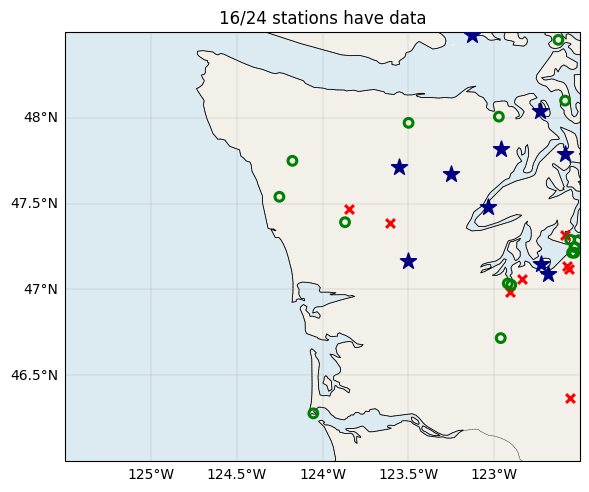

In [42]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
"""Add land/ocean/coastline context and frame the search box."""
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#f3f0ea")
ax.add_feature(cfeature.OCEAN, facecolor="#dcebf2")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.STATES, linestyle=":", linewidth=0.4)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = gl.right_labels = False

for _, row in filtered_df_station.iterrows():
    ok = row['data_available']
    if ok:
        ax.scatter(row['longitude'], row['latitude'], marker="o", s=40,
                   facecolors="none", edgecolors="green", linewidths=2.2,
                   transform=ccrs.PlateCarree(), zorder=5)
    else:
        ax.scatter(row['longitude'], row['latitude'], marker="x", s=40,
                   color="red", linewidths=2.2,
                   transform=ccrs.PlateCarree(), zorder=5)

ax.scatter(evlons, evlats, marker="*", s=150, color="navy",
           transform=ccrs.PlateCarree(), zorder=6)

n_ok = int(filtered_df_station['data_available'].sum())
ax.set_title(f"{n_ok}/{len(filtered_df_station)} stations have data")
plt.tight_layout()
plt.show()

#### **3.4 Generate final station metadata table**

In [40]:
# finally, create a new dataframe that only includes stations with data available
station_dataframe = filtered_df_station[(filtered_df_station['data_available'] == True)]
station_dataframe

,network,station,start_date,latitude,longitude,elevation,channel,sample_rate,data_available
75,US,NLWA,2006-07-05T00:00:00.000000Z,47.391700,-123.869100,640.0,HNZ,200.0,True
78,UW,BILS,2015-03-30T00:00:00.000000Z,47.539660,-124.251380,62.0,HNZ,200.0,True
81,UW,BLN,1980-01-11T00:00:00.000000Z,48.006624,-122.972646,601.0,HNZ,200.0,True
87,UW,ERW,1997-12-01T00:00:00.000000Z,48.453827,-122.626121,387.0,HNZ,200.0,True
90,UW,HURR,2017-05-10T00:00:00.000000Z,47.970350,-123.498710,1605.0,HNZ,200.0,True
93,UW,LWCK,2015-01-29T00:00:00.000000Z,46.277800,-124.053600,60.4,HNZ,200.0,True
96,UW,MAC,2018-06-25T00:00:00.000000Z,47.246700,-122.531800,112.5,HNZ,200.0,True
108,UW,OOW2,2015-03-03T00:00:00.000000Z,47.749190,-124.175440,741.0,HNZ,200.0,True
114,UW,QCDG,2011-11-16T00:00:00.000000Z,48.100020,-122.586960,52.2,HNZ,200.0,True
117,UW,QCEN,2012-06-14T00:00:00.000000Z,46.716350,-122.961900,55.4,HNZ,200.0,True


## **4. Data Store**

In this section we will store our station metadata table. Since raw waveform data is always available to stream, we do not need to store them anymore. The metadata table is sufficient to retrieve waveform when needed.

For storage, we have three options in GeoLab.
1. User home directories (any folder under `/home/jovyan`): 50 GB permanent storage (if GeoLab is accessed at least once in every six months)
2. The `\tmp` directory (a writable directory): A fast SSD drive with larger than the home directory, where data will be deleted every time the user logged out of GeoLab.
3. `scratch` bucket storage: A temporary S3 cloud storage bucket for large datasets which will be deleted after 7 days.

#### **4.1 Save event parameters** 

In [69]:
import json
# Store event-selection parameters in a dictionary
event_selection = {
    "event_time": str(event_time),
    "target_channel": target_channel,
    "pre_event_seconds": 120,
    "post_event_seconds": 480,
    "start_time": str(t1),
    "end_time": str(t2)
}

# Save as JSON
with open("event_selection.json", "w") as f:
    json.dump(event_selection, f, indent=4)

#### **4.2 Save metadata**

Because, the metadata table is small in size and we will need it consistently, the home directory is the best place to store it.

In [ ]:
# Save the filtered station dataframe to a CSV file
station_dataframe.to_csv("station_dataframe.csv", index=False)

# Save Station Inventory as StationXML
st_inv.write("station_inventory.xml", format="STATIONXML")

# Save the event catalog to a QuakeML file
ev_catalog.write("event_catalog.xml", format="QUAKEML")

#### **4.2 Size estimation of selected data**

For any cloud-scale work, a useful habit is to predict the data volume before requesting it. For each user, GeoLab has a resource quota. So it is necessary to be mindful of data volume we are requesting.

The arithmetic is simple —

$$\text{bytes} \approx n_{\text{channels}} \times \text{sample rate} \times \text{duration (s)} \times \text{bytes per sample}$$

miniSEED is compressed, so this is an *upper bound* on the uncompressed size

In [41]:
# Estimate the uncompressed size of the waveform request.
sample_rate = station_dataframe["sample_rate"].iloc[0]
duration_s = t2 - t1  # seconds in the requested waveform window
n_channels = len(station_dataframe)

nbytes = n_channels * sample_rate * duration_s * 4
mb = nbytes / 1e6

print(f"~{n_channels} channels x {sample_rate} Hz x {duration_s}s")
print(f"Estimated upper-bound volume: {mb:.1f} MB")

~16 channels x 200.0 Hz x 600.0s
Estimated upper-bound volume: 7.7 MB


## **Reflection**

In this notebook, you have gove over exploratory steps on seismic data discovery and retrieval in GeoLab, the cloud-platform provided by EarthScope. You have generated an event catalogue and station inventory which you have filtered based on station metadata so that it matches your science workflow. At the end, you store the results of your exploration.

> **Suppose, you need to go through this data discovery and retrieval steps several times, either to collect data for multiple regions or have an iterative workflow to select your dataset. In any case, which platform do you think will be faster and efficient for data discovery and retrieval, <u>GeoLab or Local Workstation?</u>**